## Setup, Data Ingestion & Returns Calculation

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sqlalchemy import create_engine
from pathlib import Path
import matplotlib.pyplot as plt

# Rubric Compliance: Use pathlib
BASE_DIR = Path('..').resolve()
DB_PATH = BASE_DIR / 'data' / 'db' / 'bluestock_mf.db'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
CHARTS_DIR = BASE_DIR / 'reports' / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

engine = create_engine(f"sqlite:///{DB_PATH}")

# Load data
df_nav = pd.read_sql("SELECT * FROM fact_nav", engine)
df_bench = pd.read_sql("SELECT * FROM dim_benchmark WHERE index_name = 'NIFTY100'", engine)
df_perf = pd.read_csv(BASE_DIR / 'data' / 'raw' / '07_scheme_performance.csv')

# Compute daily returns
pivot = df_nav.pivot(index='date', columns='amfi_code', values='nav').pct_change().dropna()
bench_ret = df_bench.set_index('date')['close_value'].pct_change().dropna()

## Advanced Metric Engine (Sharpe, Sortino, Max Drawdown)

In [2]:
results = []
rf = 0.065 / 252  # Daily Rf (RBI Repo Proxy)

for code in pivot.columns:
    fund_ret = pivot[code]
    
    # 1. Sharpe Ratio: (Rp - Rf) / Std(Rp) * sqrt(252)
    sharpe = ((fund_ret.mean() - rf) / fund_ret.std()) * np.sqrt(252)
    
    # 2. Sortino Ratio: Downside deviation
    downside_ret = fund_ret[fund_ret < 0]
    sortino = ((fund_ret.mean() * 252 - 0.065) / (downside_ret.std() * np.sqrt(252)))
    
    # 3. Max Drawdown
    cum_ret = (1 + fund_ret).cumprod()
    max_dd = (cum_ret / cum_ret.cummax() - 1).min()
    
    results.append({'amfi_code': code, 'Sharpe_Ratio': sharpe, 'Sortino': sortino, 'MaxDD': max_dd})

df_res = pd.DataFrame(results).merge(df_perf, on='amfi_code')

## OLS Regression (Alpha & Beta)

In [3]:
for code in pivot.columns:
    # Merge fund and bench returns to align dates
    data = pd.DataFrame({'fund': pivot[code], 'bench': bench_ret}).dropna()
    
    # OLS Regression
    slope, intercept, _, _, _ = stats.linregress(data['bench'], data['fund'])
    
    # Annualize Alpha
    alpha = intercept * 252 
    beta = slope
    
    # Update dataframe
    df_res.loc[df_res['amfi_code'] == code, 'Alpha'] = alpha
    df_res.loc[df_res['amfi_code'] == code, 'Beta'] = beta

# Export Alpha/Beta CSV
df_res[['amfi_code', 'Alpha', 'Beta']].to_csv(PROCESSED_DIR / 'alpha_beta.csv', index=False)

C:\Users\dheer\AppData\Local\Temp\ipykernel_4264\3626994224.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, _, _, _ = stats.linregress(data['bench'], data['fund'])
C:\Users\dheer\AppData\Local\Temp\ipykernel_4264\3626994224.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, _, _, _ = stats.linregress(data['bench'], data['fund'])
C:\Users\dheer\AppData\Local\Temp\ipykernel_4264\3626994224.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, _, _, _ = stats.linregress(data['bench'], data['fund'])
C:\Users\dheer\AppData\Local\Temp\ipykernel_4264\3626994224.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned 

## Fund Scorecard (Weighted Composite)

In [4]:
# Normalize to 0-100 (Invert for Expense Ratio and MaxDD)
for col in ['return_3yr_pct', 'Sharpe_Ratio', 'Alpha', 'expense_ratio_pct', 'MaxDD']:
    asc = True if col in ['expense_ratio_pct', 'MaxDD'] else False
    df_res[f'{col}_rank'] = df_res[col].rank(pct=True, ascending=asc) * 100

# Final Score Calculation
df_res['Final_Score'] = (
    0.30 * df_res['return_3yr_pct_rank'] + 
    0.25 * df_res['Sharpe_Ratio_rank'] + 
    0.20 * df_res['Alpha_rank'] + 
    0.15 * df_res['expense_ratio_pct_rank'] + 
    0.10 * df_res['MaxDD_rank']
)

# Export Scorecard
df_res[['amfi_code', 'scheme_name', 'Final_Score']].to_csv(PROCESSED_DIR / 'fund_scorecard.csv', index=False)

## Benchmark Comparison Chart

Tracking Error for Fund 100016: nan
Tracking Error for Fund 100025: nan
Tracking Error for Fund 100033: nan
Tracking Error for Fund 101206: nan
Tracking Error for Fund 101207: nan


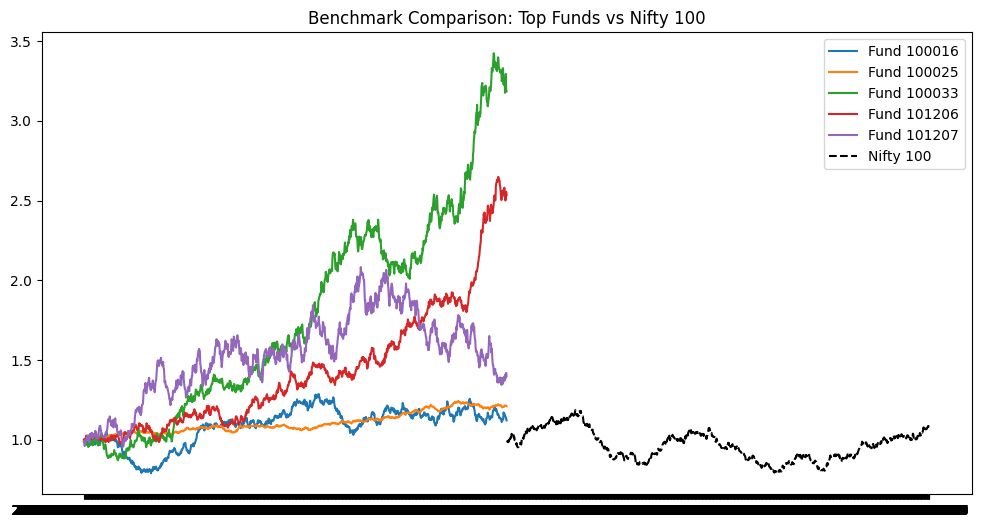

In [5]:
top_5 = df_res.nlargest(5, 'Final_Score')['amfi_code']
plt.figure(figsize=(12, 6))

for code in top_5:
    plt.plot((1 + pivot[code]).cumprod(), label=f"Fund {code}")
    
    # Tracking Error calculation
    te = (pivot[code] - bench_ret).std() * np.sqrt(252)
    print(f"Tracking Error for Fund {code}: {te:.4f}")

plt.plot((1 + bench_ret).cumprod(), label="Nifty 100", color='black', linestyle='--')
plt.title('Benchmark Comparison: Top Funds vs Nifty 100')
plt.legend()
plt.savefig(CHARTS_DIR / 'benchmark_comparison.png')